In [1]:
import os
n_cores = 4
os.environ["XLA_FLAGS"] = '--xla_force_host_platform_device_count={}'.format(n_cores)

from jax import config
config.update("jax_enable_x64", True)

import jax
import jax.numpy as jnp
import numpy as np
import pickle
from jax import jit, vmap, grad, jacrev
from jax.lax import cond, scan
import jax.random as random
key = random.PRNGKey(2022)
import jax.example_libraries.optimizers as optimizers
from jax.flatten_util import ravel_pytree
from jax.sharding import PositionalSharding
from functools import partial

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import pandas as pd

from utils import train, coords_2_strain_nn
from utils import train_colloc_parallel as train_colloc, init_params_nn, ff_nn, divergence, bd_forces, a1, a2, lr
from utils_hyperelasticity import NODE, init_layers, NODE_model_aniso, init_params_aniso, GOH_model, eval_Cauchy, eval_Cauchy_vmap, eval_P, eval_P_vmap, neohook_model
from utils_hyperelasticity import ThreeDElasticity
from fem import plotmesh, fe_solver_2D, vahid_anisohyper_inv, apply_bc_biax,plotmesh_updated
from jax_fem.core import FEM
from jax_fem.solver import solver
from jax_fem.utils import save_sol
from jax_fem.generate_mesh import box_mesh, get_meshio_cell_type, Mesh, rectangle_mesh

from PIL import Image, ImageFilter
from jaxinterp2d import interp2d

E_fun = vmap(lambda F: 0.5*(F.T@F - jnp.eye(2)))

       __       ___      ___   ___                _______  _______ .___  ___. 
      |  |     /   \     \  \ /  /               |   ____||   ____||   \/   | 
      |  |    /  ^  \     \  V  /      ______    |  |__   |  |__   |  \  /  | 
.--.  |  |   /  /_\  \     >   <      |______|   |   __|  |   __|  |  |\/|  | 
|  `--'  |  /  _____  \   /  .  \                |  |     |  |____ |  |  |  | 
 \______/  /__/     \__\ /__/ \__\               |__|     |_______||__|  |__| 
                                                                              



## 1. Generate data + pretraining

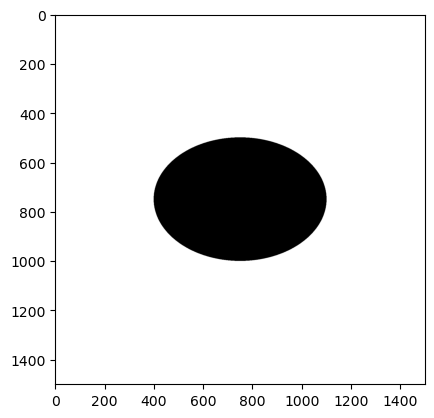

In [2]:
ele_type = 'QUAD4'
cell_type = get_meshio_cell_type(ele_type)
Nx, Ny = 50, 50
Lx, Ly = 1.0, 1.0
meshio_mesh = rectangle_mesh(Nx=Nx, Ny=Ny, domain_x=Lx, domain_y=Ly)
mesh = Mesh(meshio_mesh.points, meshio_mesh.cells_dict[cell_type])
image = Image.open('/home/amir/inverse_prob/ellipse.png')
#image = image.filter(ImageFilter.GaussianBlur(radius=60))
plt.imshow(image)
image = image.rotate(-90)
image = np.array(image)
#image = image.mean(axis=2)
image = image/image.max()

pts_x = np.linspace(0,1,image.shape[0])
pts_y = np.linspace(0,1,image.shape[1])

def coords_2_params_gt(xy):
    x, y = xy
    c = interp2d(x,y,pts_x,pts_y,image)
    return jnp.stack([0.5,0.0,0.20,0.1,0.0]) + c*jnp.stack([0.2,5,0.04,0.0,0.0])

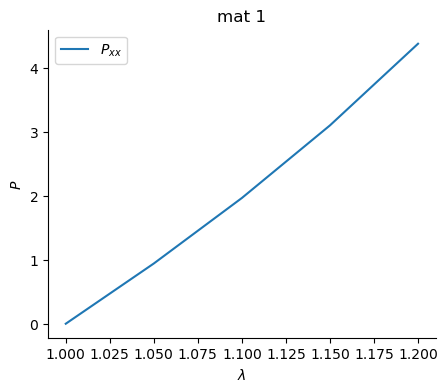

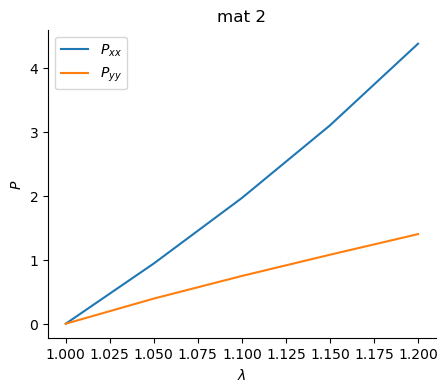

In [3]:
mat1_params = coords_2_params_gt([0.00,0.0])
mat2_params = coords_2_params_gt([0.25,0.5])
lmb_hist2 = [1.0, 1.05, 1.10, 1.15, 1.20]
mat1_P = []
mat2_Px = []
mat2_Py = []
for lmb in lmb_hist2:
    ugrad = jnp.array([[lmb-1.0, 0.0], [0.0, lmb-1.0]])
    mat1_P.append(ThreeDElasticity(GOH_model).ugrad_2_P(ugrad, mat2_params, 2)[0,0])
    mat2_Px.append(ThreeDElasticity(GOH_model).ugrad_2_P(ugrad, mat1_params, 2)[0,0])
    mat2_Py.append(ThreeDElasticity(GOH_model).ugrad_2_P(ugrad, mat1_params, 2)[1,1])

fig, ax = plt.subplots(figsize=(5,4))
ax.plot(lmb_hist2, mat1_P, label='$P_{xx}$')
# ax.plot(lmb_hist, mat2_P, label='mat 2')

ax.legend()
ax.set(xlabel='$\lambda$', ylabel='$P$', title='mat 1')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)


fig, ax = plt.subplots(figsize=(5,4))
ax.plot(lmb_hist2, mat2_Px, label='$P_{xx}$')
ax.plot(lmb_hist2, mat2_Py, label='$P_{yy}$')

ax.legend()
ax.set(xlabel='$\lambda$', ylabel='$P$', title='mat 2')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

In [4]:
GOH_P_vmap = vmap(ThreeDElasticity(GOH_model).ugrad_2_P, in_axes=(0, 0, None))
class HyperElasticity(FEM):
    def get_tensor_map(self):
        return lambda u_grad, params: ThreeDElasticity(GOH_model).ugrad_2_P(u_grad, params, self.dim)
    
    def set_params(self, params_vec):
        self.internal_vars['laplace'] = [params_vec]

In [5]:
ele_type = 'QUAD4'
cell_type = get_meshio_cell_type(ele_type)

Nx, Ny = 50, 50
Lx, Ly = 1.0, 1.0
meshio_mesh = rectangle_mesh(Nx=Nx, Ny=Ny, domain_x=Lx, domain_y=Ly)
mesh = Mesh(meshio_mesh.points, meshio_mesh.cells_dict[cell_type])


# Functions to identify the boundary nodes
def bottom(point):
    return jnp.isclose(point[1], 0., atol=1e-5)
def left(point):
    return jnp.isclose(point[0], 0., atol=1e-5)
def top(point):
    return jnp.isclose(point[1], Ly, atol=1e-5)
def right(point):
    return jnp.isclose(point[0], Lx, atol=1e-5)
def bottom_left(point):
    return jnp.logical_and(jnp.logical_and(bottom(point), left(point)), jnp.isclose(point[2], 0., atol=1e-5))


# Functions to assign dirichlet BCs
def zero_dirichlet(point):
    return 0.
def lmbx_max_dirichlet(point, lmbx_max):
    return Lx*lmbx_max - 1.0
def lmby_max_dirichlet(point, lmby_max):
    return Ly*lmby_max - 1.0


lmb_hist = [1.05, 1.10, 1.15, 1.20]
n_elem = Nx*Ny
F_hist_goh = []
P_hist_goh = []
for lmb_max in lmb_hist:
    dirichlet_bc_info = [
        [bottom,            left,           top,                                        right,                                  ],
        [1,                 0,              1,                                          0,                                      ],
        [zero_dirichlet,    zero_dirichlet, lambda p: lmby_max_dirichlet(p, lmb_max),   lambda p: lmbx_max_dirichlet(p, lmb_max)]
    ]
    problem = HyperElasticity(mesh,
                            vec=2,
                            dim=2,
                            ele_type=ele_type,
                            dirichlet_bc_info=dirichlet_bc_info)
    elem_X = problem.get_physical_quad_points().mean(1)

    # params = vmap(coords_2_params_gt)(elem_X)
    params = []
    for xy in elem_X:
        params.append(coords_2_params_gt(xy))
    params = np.expand_dims(params, 1)
    params_vec = jnp.repeat(params, axis=1, repeats=4)
    problem.set_params(params_vec)


    u = solver(problem, use_petsc=True)
    u_grad = np.mean(problem.sol_to_grad(u), axis=1)
    F = u_grad + np.eye(2)

    P = GOH_P_vmap(u_grad, params_vec[:,0,:], 2)
    
    F_hist_goh.append(F)
    P_hist_goh.append(P)
F_hist_goh = np.array(F_hist_goh)
P_hist_goh = np.array(P_hist_goh)

[08-14 12:03:21][DEBUG] jax_fem: Computing shape function values, gradients, etc.
[08-14 12:03:21][DEBUG] jax_fem: ele_type = QUAD4, quad_points.shape = (num_quads, dim) = (4, 2)
[08-14 12:03:21][DEBUG] jax_fem: face_quad_points.shape = (num_faces, num_face_quads, dim) = (4, 2, 2)
[08-14 12:03:22][DEBUG] jax_fem: Done pre-computations, took 0.795250415802002 [s]
[08-14 12:03:22][INFO] jax_fem: Solving a problem with 2500 cells, 2601x2 = 5202 dofs.
[08-14 12:03:25][DEBUG] jax_fem: Calling the row elimination solver for imposing Dirichlet B.C.
[08-14 12:03:25][DEBUG] jax_fem: Start timing
[08-14 12:03:25][DEBUG] jax_fem: Computing cell Jacobian and cell residual...
[08-14 12:03:26][DEBUG] jax_fem: Function split_and_compute_cell took 1.3516 seconds
[08-14 12:03:27][DEBUG] jax_fem: Creating sparse matrix with scipy...
[08-14 12:03:27][DEBUG] jax_fem: Linear guess solve...
[08-14 12:03:27][DEBUG] jax_fem: PETSc - Solving with ksp_type = bcgsl, pc = ilu
[08-14 12:03:27][DEBUG] jax_fem: PETS

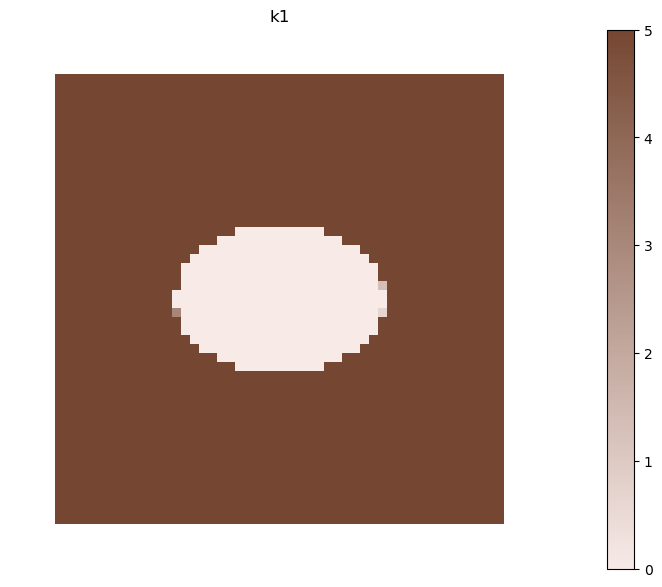

In [6]:
natural_brown_cmap = LinearSegmentedColormap.from_list(
    "natural_brown",
    [ "#f7eae7", "#754732" ],  # dark brown → light brown → pale peach
    N=256)
plotmesh(mesh.cells, mesh.points, params[:,0,1], title='k1',ec='none',cmap=natural_brown_cmap);

In [7]:
t_hist = np.arange(len(lmb_hist))
range_minmax=np.zeros((2,))
id=0
for t, F, P in zip(t_hist, F_hist_goh, P_hist_goh):
    E = E_fun(F)
    evals, efuns = jnp.linalg.eigh(E)
    E_11, E_22 = evals.T

    mps = np.maximum(E_11, E_22)
    if t==0:
        range_minmax[0]=mps.min()
        range_minmax[1]=mps.max()
    else:
        range_minmax[0]=np.min([mps.min(),range_minmax[0]])
        range_minmax[1]=np.max([mps.max(),range_minmax[1]])
    id+=1

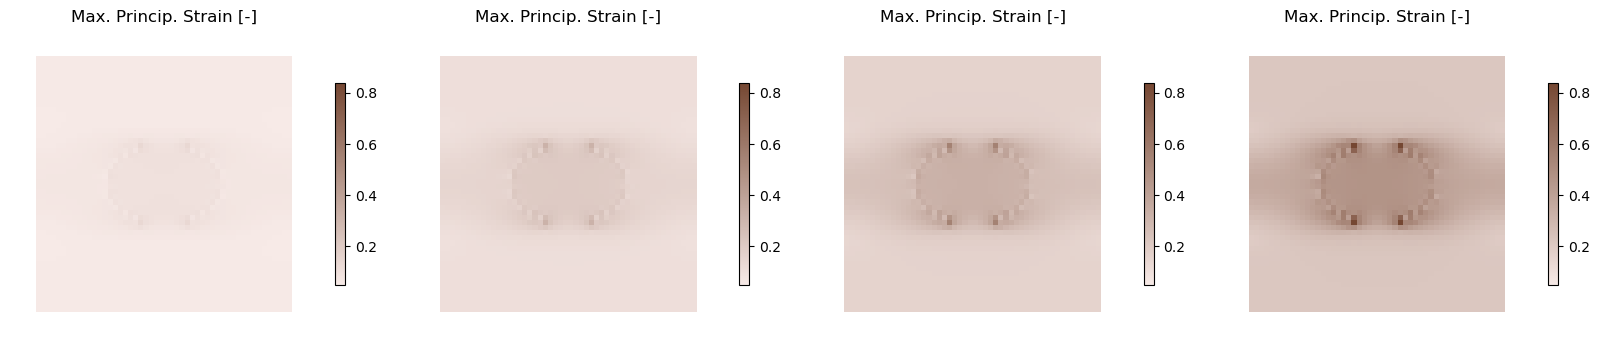

In [8]:
###here I am using the same color bar range 
fig, axes = plt.subplots(1,4,figsize=(20,4))
strains = []
t_hist = np.arange(len(lmb_hist))
#range_minmax=np.zeros((4,2))
id=0
for t, F, P, ax in zip(t_hist, F_hist_goh, P_hist_goh, axes):
    E = E_fun(F)
    evals, efuns = jnp.linalg.eigh(E)
    E_11, E_22 = evals.T

    mps = np.maximum(E_11, E_22)
    # range_minmax[id,0]=mps.min()
    # range_minmax[id,1]=mps.max()
    # plotmesh(mesh.cells, mesh.points, mps, title='Max. Princip. Strain [-]', ax=ax,ec='None');
    plotmesh_updated(mesh.cells, mesh.points, mps, range_minmax[0],range_minmax[1],title='Max. Princip. Strain [-]', ax=ax,ec='None',cmap=natural_brown_cmap) 
    id+=1

    strains.append(np.array([t*np.ones(len(F)), F[:,0,0], F[:,0,1], F[:,1,0], F[:,1,1]]))
strains = np.hstack(strains)

In [29]:
print(range_minmax)

[0.04749 0.83774]


### Coords_2_strain NN

In [30]:
# instead of using a 2D spline, use a NN to get the strain field for a given (x,y)
def loss_coords_2_strain(params, X, key):
    inp, out_gt = X[:,:3], X[:,3:] #inp: x,y,lmb and out_gt=eps_xx, eps_yy
    t = inp[:,2:3]
    out_pr = coords_2_strain_nn(inp, params)
    out_gt = out_gt/(t+1) #dividing by t+1 just for some regularization
    out_pr = out_pr/(t+1) #dividing by t+1 just for some regularization
    return jnp.mean((out_pr-out_gt)**2)

n_ff = 100 # 10 cosines and 10 sines in the fourier features
n_inp = 2 # x, y
ff_params = np.random.normal(size=n_inp*n_ff).reshape([n_inp,n_ff])*0.5
nn_layers = [2*n_ff+1,40,40,4]
nn_params = init_params_nn(nn_layers, key)
coord_2_strain_params = [ff_params, nn_params]

opt_init, opt_update, get_params = optimizers.adam(5.e-4)
opt_state = opt_init(coord_2_strain_params)

X = np.vstack([elem_X, elem_X, elem_X, elem_X])
inp = np.hstack([X, strains.T])
coord_2_strain_params, train_loss, _ = train(loss_coords_2_strain, inp, get_params, opt_update, opt_state, key, nIter = 100000, print_freq=1000, batch_size=1000)

it 1000, train loss = 1.538556e-04
it 2000, train loss = 7.955735e-05
it 3000, train loss = 6.052308e-05
it 4000, train loss = 5.452902e-05
it 5000, train loss = 4.173580e-05
it 6000, train loss = 4.876453e-05
it 7000, train loss = 4.323688e-05
it 8000, train loss = 3.963421e-05
it 9000, train loss = 3.551019e-05
it 10000, train loss = 2.802159e-05
it 11000, train loss = 2.981977e-05
it 12000, train loss = 2.731920e-05
it 13000, train loss = 1.893469e-05
it 14000, train loss = 2.507737e-05
it 15000, train loss = 2.106875e-05
it 16000, train loss = 1.676583e-05
it 17000, train loss = 1.913820e-05
it 18000, train loss = 1.916350e-05
it 19000, train loss = 1.436251e-05
it 20000, train loss = 1.523672e-05
it 21000, train loss = 1.634000e-05
it 22000, train loss = 1.070000e-05
it 23000, train loss = 1.316810e-05
it 24000, train loss = 1.236290e-05
it 25000, train loss = 1.193920e-05
it 26000, train loss = 1.141999e-05
it 27000, train loss = 1.089685e-05
it 28000, train loss = 1.269675e-05
i

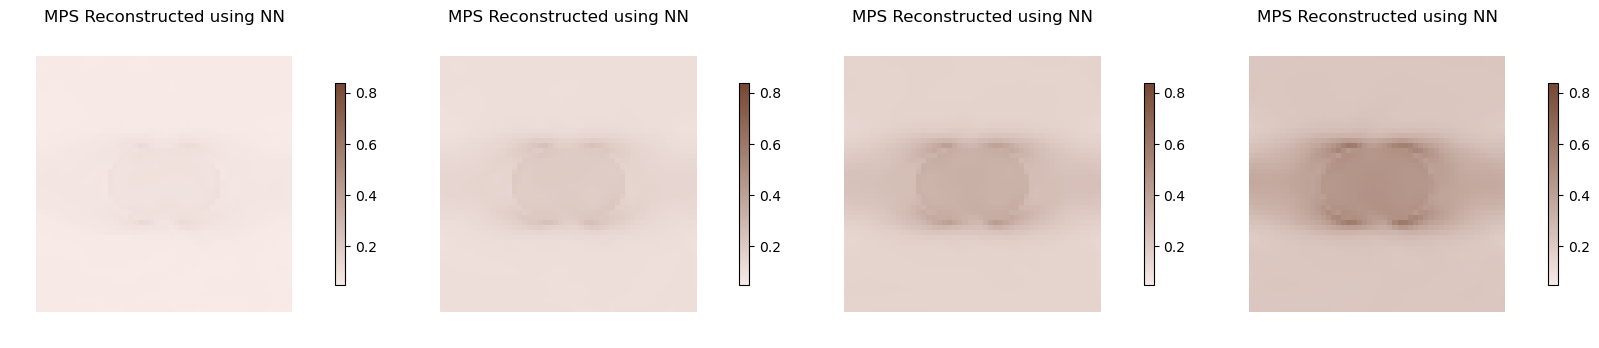

In [31]:
fig, axes = plt.subplots(1,4,figsize=(20,4))
# vmin_list = [0.05, 0.099, 0.15, 0.2] 
# vmax_list = [.135, 0.32, 0.55, 0.82] 
id=0
for t in t_hist:
    ax = axes[t]
    aux = np.hstack([elem_X, t*np.ones_like(elem_X[:,:1])])
    F_xx, F_xy, F_yx, F_yy = coords_2_strain_nn(aux, coord_2_strain_params).T
    F = np.stack([F_xx, F_xy, F_yx, F_yy]).T.reshape([-1,2,2])
    
    E = E_fun(F)
    evals, efuns = jnp.linalg.eigh(E)
    E_11, E_22 = evals.T
    mps = np.maximum(E_11, E_22)
    plotmesh_updated(mesh.cells, mesh.points, mps, range_minmax[0],range_minmax[1],title='MPS Reconstructed using NN', ax=ax,ec='None',cmap=natural_brown_cmap)
    id+=1


In [11]:
# identify the boundaries
rgt_bd_elems = []
top_bd_elems = []
lft_bd_elems = []
bot_bd_elems = []
for i, e in enumerate(mesh.cells):
    if any([mesh.points[e[i],0]>0.99 for i in range(4)]):
        rgt_bd_elems.append(i)
    if any([mesh.points[e[i],1]>0.99 for i in range(4)]):
        top_bd_elems.append(i)
    if any([mesh.points[e[i],0]<0.01 for i in range(4)]):
        lft_bd_elems.append(i)
    if any([mesh.points[e[i],1]<0.01 for i in range(4)]):
        bot_bd_elems.append(i)

# get the reaction forces by integrating the stresses of the boundary elements
rgt_bd_frc = np.sum(P_hist_goh[:,rgt_bd_elems,0,0], axis=1)
lft_bd_frc = np.sum(P_hist_goh[:,lft_bd_elems,0,0], axis=1)
top_bd_frc = np.sum(P_hist_goh[:,top_bd_elems,1,1], axis=1)
bot_bd_frc = np.sum(P_hist_goh[:,bot_bd_elems,1,1], axis=1)
Force_x = jnp.array(0.5*(rgt_bd_frc + lft_bd_frc))
Force_y = jnp.array(0.5*(top_bd_frc + bot_bd_frc))

# get the center points of the elements
rgt_bd_X = elem_X[rgt_bd_elems]
top_bd_X = elem_X[top_bd_elems]
lft_bd_X = elem_X[lft_bd_elems]
bot_bd_X = elem_X[bot_bd_elems]
bd_X = rgt_bd_X, top_bd_X, lft_bd_X, bot_bd_X

In [39]:
len(elem_X)

2500

In [12]:
# Homogenize the strains
F_xx_mean = np.mean(F_hist_goh[:,:,0,0], axis=1)
F_xy_mean = np.mean(F_hist_goh[:,:,0,1], axis=1)
F_yx_mean = np.mean(F_hist_goh[:,:,1,0], axis=1)
F_yy_mean = np.mean(F_hist_goh[:,:,1,1], axis=1)

P_xx_mean = Force_x/len(rgt_bd_elems)
P_yy_mean = Force_y/len(top_bd_elems)
inputs = np.array([F_xx_mean, F_xy_mean, F_yx_mean, F_yy_mean, P_xx_mean, P_yy_mean]).T

n_neurons = 4
# Define the loss function for when training all params
@jit
def loss_stress(params, x, key):
    model = NODE_model_aniso(params)
    F_xx, F_xy, F_yx, F_yy, P_xx_gt, P_yy_gt = x.T
    P = eval_P_vmap(F_xx, F_xy, F_yx, F_yy, model)
    P_xx_pr, P_yy_pr = P[:,0,0], P[:,1,1]
    return np.mean((P_xx_pr-P_xx_gt)**2+(P_yy_pr-P_yy_gt)**2)

# Initialize NODEs and the optimizer
key = random.PRNGKey(0)
common_layers = [1, n_neurons, n_neurons]
sample_layers = [n_neurons,1]
node_params = init_params_aniso(common_layers, sample_layers, key)
opt_init, opt_update, get_params = optimizers.adam(5.e-4) #Original: 1.e-4
opt_state = opt_init(node_params)

# Train
node_params, train_loss, _ = train(loss_stress, inputs, get_params, opt_update, opt_state, key, nIter = 20000, print_freq=1000)

it 1000, train loss = 6.283758e-02
it 2000, train loss = 2.226261e-02
it 3000, train loss = 1.907331e-02
it 4000, train loss = 1.697259e-02
it 5000, train loss = 1.443230e-02
it 6000, train loss = 1.123313e-02
it 7000, train loss = 7.088453e-03
it 8000, train loss = 3.088866e-03
it 9000, train loss = 1.046062e-03
it 10000, train loss = 2.746561e-04
it 11000, train loss = 8.898713e-05
it 12000, train loss = 2.565592e-05
it 13000, train loss = 8.705324e-06
it 14000, train loss = 3.153061e-06
it 15000, train loss = 2.619245e-06
it 16000, train loss = 2.399783e-06
it 17000, train loss = 2.155036e-06
it 18000, train loss = 1.789323e-06
it 19000, train loss = 1.531796e-06
it 20000, train loss = 1.437711e-06


In [13]:
mymodel = NODE_model_aniso(node_params)
P = eval_P_vmap(F_xx_mean, F_xy_mean, F_yx_mean, F_yy_mean, mymodel)
P_xx_pr, P_yy_pr = P[:,0,0], P[:,1,1]
print('gt P_xx & P_yy: ', P_xx_mean, P_yy_mean)
print('pr P_xx & P_yy: ', P_xx_pr, P_yy_pr)

gt P_xx & P_yy:  [0.79583 1.62702 2.51762 3.49266] [0.36971 0.68996 0.97676 1.24236]
pr P_xx & P_yy:  [0.7957  1.62594 2.51894 3.49222] [0.37101 0.68989 0.97587 1.24274]


In [42]:
# Fit a function Λ that maps x,y ∈ [0,1] to the individual-specific parameters of this NODE with a maximum variance of, say, 1%
phi, unravel = ravel_pytree(node_params)
n_phi = len(phi)

# ff_params = coord_2_strain_params[0]
# ff_nn2 = lambda x, nn_params: ff_nn(x, [ff_params, nn_params])
def loss_Lambda(params, inp, key):
    out_pr = ff_nn(inp, params)
    return jnp.mean((out_pr-phi)**2)

n_ff = 10
ff_params = np.random.normal(size=2*n_ff).reshape([2,n_ff])
nn_layers = [2*n_ff,40,40,n_phi]
nn_params = init_params_nn(nn_layers, key)
Lambda_params = [ff_params, nn_params]
opt_init, opt_update, get_params = optimizers.adam(5.e-4) #Original: 1.e-4
opt_state = opt_init(Lambda_params)

inp = np.array(np.meshgrid(np.linspace(0,1,20), np.linspace(0,1,20))).reshape([2,-1]).T
Lambda_params, train_loss, _ = train(loss_Lambda, inp, get_params, opt_update, opt_state, key, nIter = 10000, print_freq=1000)

it 1000, train loss = 2.223212e-04
it 2000, train loss = 6.143226e-05
it 3000, train loss = 2.655358e-05
it 4000, train loss = 1.357651e-05
it 5000, train loss = 7.396896e-06
it 6000, train loss = 4.177328e-06
it 7000, train loss = 2.386354e-06
it 8000, train loss = 1.367025e-06
it 9000, train loss = 8.381187e-07
it 10000, train loss = 8.210745e-07


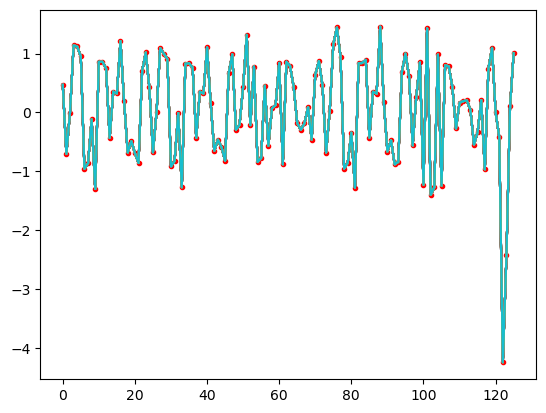

In [43]:
fig, ax = plt.subplots()
ax.plot(phi, 'r.-')
for y in np.linspace(0,1,4):
    for x in np.linspace(0,1,10):
        params = ff_nn(np.array([x,y]).reshape([1,-1]), Lambda_params)
        ax.plot(params[0])

In [44]:
with open('inhomogeneous_paper_pre.npy', 'wb') as f:
    pickle.dump([coord_2_strain_params, node_params, Lambda_params, mesh, elem_X, Force_x, Force_y, strains,
                 bd_X, lmb_hist, P_hist_goh, F_hist_goh, t_hist], f)

In [9]:
with open('inhomogeneous_paper_pre.npy', 'rb') as f:
    coord_2_strain_params, node_params, Lambda_params, mesh, elem_X, Force_x, Force_y, strains,bd_X, lmb_hist, P_hist_goh, F_hist_goh, t_hist=pickle.load(f)

In [10]:
_, unravel = ravel_pytree(node_params)
NODE_w_unravel = lambda params: NODE_model_aniso(unravel(params))
coords_2_strain_nn_ff = lambda x, params: coords_2_strain_nn(x, params)
ff_nn_ff = lambda x, params: ff_nn(x, params)

In [ ]:
def get_P(X, Y, t, Lambda_params, coord_2_strain_params, model):
    F_xx, F_xy, F_yx, F_yy = coords_2_strain_nn_ff(jnp.array([X,Y,t])[None,:], coord_2_strain_params).flatten()
    # get NODE individual-specific params, phi, from the Lambda NN
    Lambda_inp = jnp.array([X,Y]).reshape([-1,2])
    phi = ff_nn_ff(Lambda_inp, Lambda_params).flatten()
    # Make predictions with this NODE
    ugrad = jnp.array([[F_xx-1.0, F_xy],[F_yx, F_yy-1.0]])
    P = ThreeDElasticity(model).ugrad_2_P(ugrad, phi, 2)
    return P[0,0], P[1,0], P[0,1], P[1,1]
get_P_vmap = vmap(get_P, in_axes=(0,0,0,None,None,None), out_axes=(0,0,0,0))

get_Pxx = lambda X, Y, t, a, b, c: get_P(X, Y, t, a, b, c)[0]
get_Pyx = lambda X, Y, t, a, b, c: get_P(X, Y, t, a, b, c)[1]
get_Pxy = lambda X, Y, t, a, b, c: get_P(X, Y, t, a, b, c)[2]
get_Pyy = lambda X, Y, t, a, b, c: get_P(X, Y, t, a, b, c)[3]

Grad_Pxx_X = vmap(grad(get_Pxx, argnums=0), in_axes=(0,0,0,None,None,None), out_axes=0) # should return dsgm_xx/dx
Grad_Pyx_X = vmap(grad(get_Pyx, argnums=0), in_axes=(0,0,0,None,None,None), out_axes=0)
Grad_Pxy_Y = vmap(grad(get_Pyx, argnums=1), in_axes=(0,0,0,None,None,None), out_axes=0)
Grad_Pyy_Y = vmap(grad(get_Pyy, argnums=1), in_axes=(0,0,0,None,None,None), out_axes=0)

@partial(jit, static_argnums=(4,))
def bd_forces(Lambda_params, t, bd_X, c2s_params, model):
    rgt_bd_X, top_bd_X, lft_bd_X, bot_bd_X = bd_X
    rgt_bd_P = get_P_vmap(rgt_bd_X[:,0], rgt_bd_X[:,1], t*jnp.ones_like(rgt_bd_X[:,0]), Lambda_params, c2s_params, model)
    top_bd_P = get_P_vmap(top_bd_X[:,0], top_bd_X[:,1], t*jnp.ones_like(top_bd_X[:,0]), Lambda_params, c2s_params, model)
    lft_bd_P = get_P_vmap(lft_bd_X[:,0], lft_bd_X[:,1], t*jnp.ones_like(lft_bd_X[:,0]), Lambda_params, c2s_params, model)
    bot_bd_P = get_P_vmap(bot_bd_X[:,0], bot_bd_X[:,1], t*jnp.ones_like(bot_bd_X[:,0]), Lambda_params, c2s_params, model)

    rgt_bd_frc = jnp.sum(rgt_bd_P[0]*1.0) # Assume area of edge = 1.0
    top_bd_frc = jnp.sum(top_bd_P[3]*1.0)
    lft_bd_frc = jnp.sum(lft_bd_P[0]*1.0)
    bot_bd_frc = jnp.sum(bot_bd_P[3]*1.0)
    return rgt_bd_frc, top_bd_frc, lft_bd_frc, bot_bd_frc

@partial(jit, static_argnums=(3,))
def divergence(Lambda_params, XYt, c2s_params, model):
    dPxx_dX = Grad_Pxx_X(XYt[:,0], XYt[:,1], XYt[:,2], Lambda_params, c2s_params, model)
    dPxy_dY = Grad_Pxy_Y(XYt[:,0], XYt[:,1], XYt[:,2], Lambda_params, c2s_params, model)
    dPyx_dX = Grad_Pyx_X(XYt[:,0], XYt[:,1], XYt[:,2], Lambda_params, c2s_params, model)
    dPyy_dY = Grad_Pyy_Y(XYt[:,0], XYt[:,1], XYt[:,2], Lambda_params, c2s_params, model)
    
    Div_X = jnp.mean(dPxx_dX + dPxy_dY)
    Div_Y = jnp.mean(dPyx_dX + dPyy_dY)
    return Div_X, Div_Y
#%%
# Train
a1 = 10000
@jit
def loss(Lambda_params, XYt_colloc):

    P_pred = get_P_vmap(XYt_colloc[:,0],XYt_colloc[:,1], XYt_colloc[:,2], Lambda_params, coord_2_strain_params, NODE_w_unravel)
    P_xx = P_xx_mean[jnp.array(XYt_colloc[:,2], int)]
    P_yy = P_yy_mean[jnp.array(XYt_colloc[:,2], int)]

    loss_P = jnp.mean((P_pred[0] - P_xx)**2 + (P_pred[3] - P_yy)**2)
    # loss_F = 0.0
    
    return loss_P

lr = optimizers.exponential_decay(1e-3, 10000, 0.9)
sharding = PositionalSharding(jax.devices()).reshape(n_cores, 1)
opt_init, opt_update, get_params = optimizers.adam(lr) 
opt_state = opt_init(Lambda_params)

node_X_ext = jnp.hstack([mesh.points, t_hist[-1]*np.ones_like(mesh.points[:,:1])])
metric1 = lambda params, X:  bd_forces(params, t_hist[-1], bd_X, coord_2_strain_params, NODE_w_unravel)
metric2 = lambda params, X: divergence(params, node_X_ext, coord_2_strain_params, NODE_w_unravel)

Lambda_params, val_loss, metrics = train_colloc(loss, [mesh.points, t_hist], get_params, opt_update, opt_state, 
                                            key, sharding, 'cross', nIter = 30000, print_freq=1000, batch_size=1000)

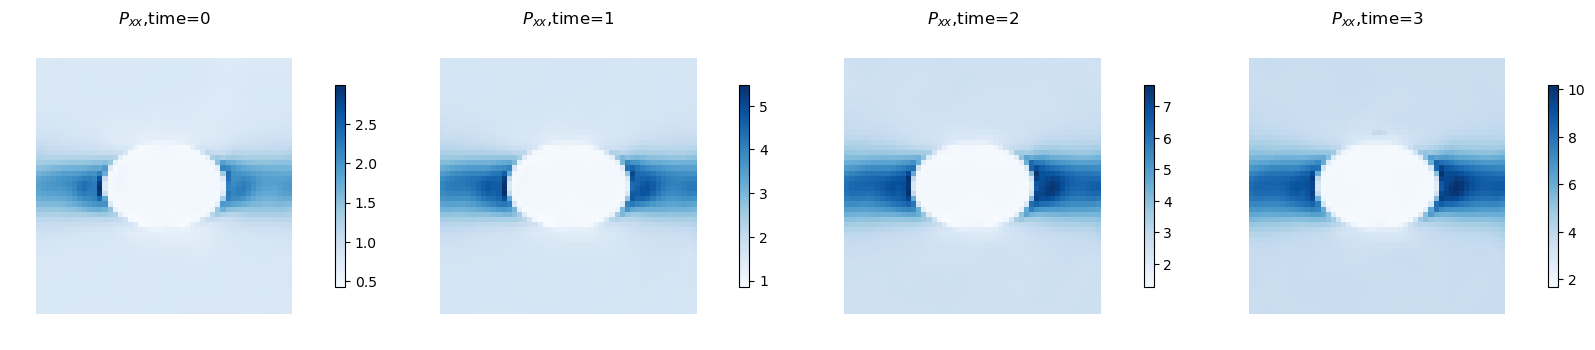

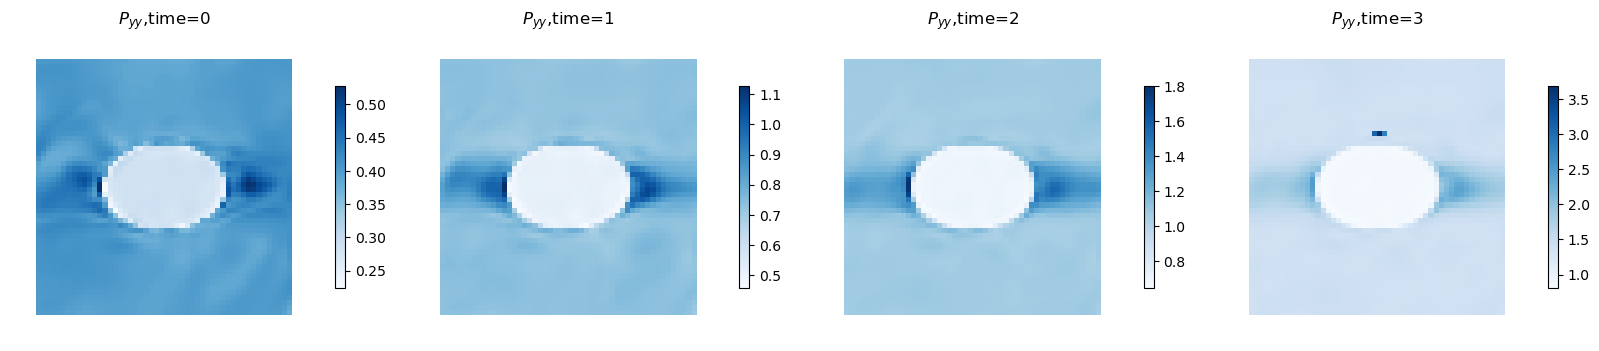

In [13]:
def get_P_pretraining_plot(F, X,Y,Lambda_params, model):
    F_xx=F[0,0]
    F_xy=F[0,1]
    F_yx=F[1,0]
    F_yy=F[1,1]
    #F_xx, F_xy, F_yx, F_yy = coords_2_strain_nn_ff(jnp.array([X,Y,t])[None,:], coord_2_strain_params).flatten()
    # get NODE individual-specific params, phi, from the Lambda NN
    Lambda_inp = jnp.array([X,Y]).reshape([-1,2])
    phi = ff_nn_ff(Lambda_inp, Lambda_params).flatten()
    # Make predictions with this NODE
    ugrad = jnp.array([[F_xx-1.0, F_xy],[F_yx, F_yy-1.0]])
    P = ThreeDElasticity(model).ugrad_2_P(ugrad, phi, 2)
    return P[0,0], P[1,0], P[0,1], P[1,1]
get_P_pretraining_plot_vmap = vmap(get_P_pretraining_plot, in_axes=(0,0,0,None,None), out_axes=(0,0,0,0))
lmb_hist_plot = [1.05, 1.10, 1.15, 1.20]
t_hist = len(lmb_hist_plot )
n_plots = len(lmb_hist_plot)  
n_cols = 4
n_rows = (n_plots + n_cols - 1) // n_cols 
t_hist =np.arange(0, t_hist)
# c_range=np.ones((n_cols,2))
# c_range[:,[0]]=100000*c_range[:,[0]]
# c_range[:,[1]]=-100000*c_range[:,[1]]
ff_nn_ff = lambda x, params: ff_nn(x, params)
_, unravel = ravel_pytree(node_params)
NODE_w_unravel = lambda params: NODE_model_aniso(unravel(params))
id_for_range=0
fig_x, axes_x = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
axes_x = axes_x.flatten()
fig_y, axes_y = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
axes_y = axes_y.flatten()
for lam in lmb_hist_plot:
    ax_x = axes_x[id_for_range]
    ax_y = axes_y[id_for_range]
    uniform_F= lam *np.eye(2).reshape(1, 2, 2)
    uniform_F_batch= np.repeat(uniform_F, elem_X.shape[0], axis=0)
    P_xx, P_xy,P_yx,P_yy=get_P_pretraining_plot_vmap(uniform_F_batch, elem_X[:,0],elem_X[:,1],Lambda_params,NODE_w_unravel)
    title=fr'$P_{{xx}}$,time={id_for_range}'
    plotmesh(mesh.cells, mesh.points, P_xx,title=title, ax=ax_x,ec='None')
    title=fr'$P_{{yy}}$,time={id_for_range}'
    plotmesh(mesh.cells, mesh.points, P_yy,title=title, ax=ax_y,ec='None')
    id_for_range+=1

In [49]:
with open('inhomogeneous_paper_second_pretraining.pickle', 'wb') as f:
    pickle.dump([Lambda_params,val_loss, metrics], f)

In [12]:
with open('inhomogeneous_paper_second_pretraining.pickle', 'rb') as f:
    Lambda_params,val_loss, metrics=pickle.load(f)

## 2. Retrain

In [14]:
_, unravel = ravel_pytree(node_params)
NODE_w_unravel = lambda params: NODE_model_aniso(unravel(params))

In [34]:
coords_2_strain_nn_ff = lambda x, params: coords_2_strain_nn(x, params)
ff_nn_ff = lambda x, params: ff_nn(x, params)

In [12]:
def get_P(X, Y, t, Lambda_params, coord_2_strain_params, model):
    F_xx, F_xy, F_yx, F_yy = coords_2_strain_nn_ff(jnp.array([X,Y,t])[None,:], coord_2_strain_params).flatten()
    # get NODE individual-specific params, phi, from the Lambda NN
    Lambda_inp = jnp.array([X,Y]).reshape([-1,2])
    phi = ff_nn_ff(Lambda_inp, Lambda_params).flatten()
    # Make predictions with this NODE
    ugrad = jnp.array([[F_xx-1.0, F_xy],[F_yx, F_yy-1.0]])
    P = ThreeDElasticity(model).ugrad_2_P(ugrad, phi, 2)
    return P[0,0], P[1,0], P[0,1], P[1,1]
get_P_vmap = vmap(get_P, in_axes=(0,0,0,None,None,None), out_axes=(0,0,0,0))

get_Pxx = lambda X, Y, t, a, b, c: get_P(X, Y, t, a, b, c)[0]
get_Pyx = lambda X, Y, t, a, b, c: get_P(X, Y, t, a, b, c)[1]
get_Pxy = lambda X, Y, t, a, b, c: get_P(X, Y, t, a, b, c)[2]
get_Pyy = lambda X, Y, t, a, b, c: get_P(X, Y, t, a, b, c)[3]

Grad_Pxx_X = vmap(grad(get_Pxx, argnums=0), in_axes=(0,0,0,None,None,None), out_axes=0) # should return dsgm_xx/dx
Grad_Pyx_X = vmap(grad(get_Pyx, argnums=0), in_axes=(0,0,0,None,None,None), out_axes=0)
Grad_Pxy_Y = vmap(grad(get_Pyx, argnums=1), in_axes=(0,0,0,None,None,None), out_axes=0)
Grad_Pyy_Y = vmap(grad(get_Pyy, argnums=1), in_axes=(0,0,0,None,None,None), out_axes=0)

@partial(jit, static_argnums=(4,))
def bd_forces(Lambda_params, t, bd_X, c2s_params, model):
    rgt_bd_X, top_bd_X, lft_bd_X, bot_bd_X = bd_X
    rgt_bd_P = get_P_vmap(rgt_bd_X[:,0], rgt_bd_X[:,1], t*jnp.ones_like(rgt_bd_X[:,0]), Lambda_params, c2s_params, model)
    top_bd_P = get_P_vmap(top_bd_X[:,0], top_bd_X[:,1], t*jnp.ones_like(top_bd_X[:,0]), Lambda_params, c2s_params, model)
    lft_bd_P = get_P_vmap(lft_bd_X[:,0], lft_bd_X[:,1], t*jnp.ones_like(lft_bd_X[:,0]), Lambda_params, c2s_params, model)
    bot_bd_P = get_P_vmap(bot_bd_X[:,0], bot_bd_X[:,1], t*jnp.ones_like(bot_bd_X[:,0]), Lambda_params, c2s_params, model)

    rgt_bd_frc = jnp.sum(rgt_bd_P[0]*1.0) # Assume area of edge = 1.0
    top_bd_frc = jnp.sum(top_bd_P[3]*1.0)
    lft_bd_frc = jnp.sum(lft_bd_P[0]*1.0)
    bot_bd_frc = jnp.sum(bot_bd_P[3]*1.0)
    return rgt_bd_frc, top_bd_frc, lft_bd_frc, bot_bd_frc

@partial(jit, static_argnums=(3,))
def divergence(Lambda_params, XYt, c2s_params, model):
    dPxx_dX = Grad_Pxx_X(XYt[:,0], XYt[:,1], XYt[:,2], Lambda_params, c2s_params, model)
    dPxy_dY = Grad_Pxy_Y(XYt[:,0], XYt[:,1], XYt[:,2], Lambda_params, c2s_params, model)
    dPyx_dX = Grad_Pyx_X(XYt[:,0], XYt[:,1], XYt[:,2], Lambda_params, c2s_params, model)
    dPyy_dY = Grad_Pyy_Y(XYt[:,0], XYt[:,1], XYt[:,2], Lambda_params, c2s_params, model)
    
    Div_X = jnp.mean(dPxx_dX + dPxy_dY)
    Div_Y = jnp.mean(dPyx_dX + dPyy_dY)
    return Div_X, Div_Y

In [54]:
# Train
a1 = 10000
@jit
def loss(Lambda_params, XYt_colloc):
    Div_x, Div_y = divergence(Lambda_params, XYt_colloc, coord_2_strain_params, NODE_w_unravel)
    loss_Div = a1*(Div_x**2 + Div_y**2)

    def bd_forces_loss(_, t):
        F_rgt, F_top, F_lft, F_bot = bd_forces(Lambda_params, t, bd_X, coord_2_strain_params, NODE_w_unravel)
        Fx = Force_x[jnp.array(t, int)]
        Fy = Force_y[jnp.array(t, int)]
        return None, a2*((F_rgt-Fx)**2 + (F_top-Fy)**2 + (F_lft-Fx)**2 + (F_bot-Fy)**2)
    loss_F = jnp.mean(scan(bd_forces_loss, init=None, xs=t_hist)[1])
    # loss_F = 0.0
    
    return loss_Div + loss_F

lr = optimizers.exponential_decay(1e-4, 5000, 0.5)
sharding = PositionalSharding(jax.devices()).reshape(n_cores, 1)
opt_init, opt_update, get_params = optimizers.adam(lr) 
opt_state = opt_init(Lambda_params)

node_X_ext = jnp.hstack([mesh.points, t_hist[-1]*np.ones_like(mesh.points[:,:1])])
metric1 = lambda params, X:  bd_forces(params, t_hist[-1], bd_X, coord_2_strain_params, NODE_w_unravel)
metric2 = lambda params, X: divergence(params, node_X_ext, coord_2_strain_params, NODE_w_unravel)

Lambda_params, val_loss, metrics = train_colloc(loss, [mesh.points, t_hist], get_params, opt_update, opt_state, 
                                            key, sharding, 'cross', nIter = 20000, print_freq=1000, batch_size=1000)

with open('inhomogeneous_paper_post.npy', 'wb') as f:
    pickle.dump([mesh, elem_X, strains, Force_x, Force_y, node_params, Lambda_params, val_loss, metrics, t_hist, lmb_hist], f)

2025-02-07 22:17:09.028479: E external/xla/xla/service/slow_operation_alarm.cc:65] 
********************************
[Compiling module jit_step_colloc] Very slow compile? If you want to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
********************************
2025-02-07 22:20:59.767001: E external/xla/xla/service/slow_operation_alarm.cc:133] The operation took 5m50.742662142s

********************************
[Compiling module jit_step_colloc] Very slow compile? If you want to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
********************************


it 1, val loss = 7.580586e+01


2025-02-07 22:28:14.959978: E external/xla/xla/service/slow_operation_alarm.cc:133] The operation took 5m36.617374651s

********************************
[Compiling module jit_step_colloc] Very slow compile? If you want to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
********************************


it 1001, val loss = 4.217246e+01
it 2001, val loss = 1.005221e+02
it 3001, val loss = 6.628366e+01
it 4001, val loss = 4.096696e+01
it 5001, val loss = 4.696115e+01
it 6001, val loss = 4.672181e+01
it 7001, val loss = 3.848692e+01
it 8001, val loss = 4.460877e+01
it 9001, val loss = 3.381348e+01
it 10001, val loss = 3.901785e+01
it 11001, val loss = 4.165696e+01
it 12001, val loss = 2.183557e+01
it 13001, val loss = 2.490067e+01
it 14001, val loss = 2.888132e+01
it 15001, val loss = 1.757611e+01
it 16001, val loss = 2.970798e+01
it 17001, val loss = 2.252480e+01
it 18001, val loss = 2.077571e+01
it 19001, val loss = 2.646529e+01


## 3. Test

In [15]:
with open('inhomogeneous_paper_post.npy', 'rb') as f:
    mesh, elem_X, strains, Force_x, Force_y, node_params, Lambda_params, val_loss, metrics, t_hist, lmb_hist = pickle.load(f)
_, unravel = ravel_pytree(node_params)
NODE_w_unravel = lambda params: NODE_model_aniso(unravel(params))
ele_type = 'QUAD4'
cell_type = get_meshio_cell_type(ele_type)

Nx, Ny = 50, 50
Lx, Ly = 1.0, 1.0
meshio_mesh = rectangle_mesh(Nx=Nx, Ny=Ny, domain_x=Lx, domain_y=Ly)
mesh = Mesh(meshio_mesh.points, meshio_mesh.cells_dict[cell_type])
def coords_2_params_gt(xy):
    x, y = xy
    c = interp2d(x,y,pts_x,pts_y,image)
    return jnp.stack([0.5,0.0,0.20,0.1,0.0]) + c*jnp.stack([0.2,5.0,0.04,0.0,0.0])

[Text(0.5, 0, 'Iteration'), Text(0, 0.5, 'Validation loss')]

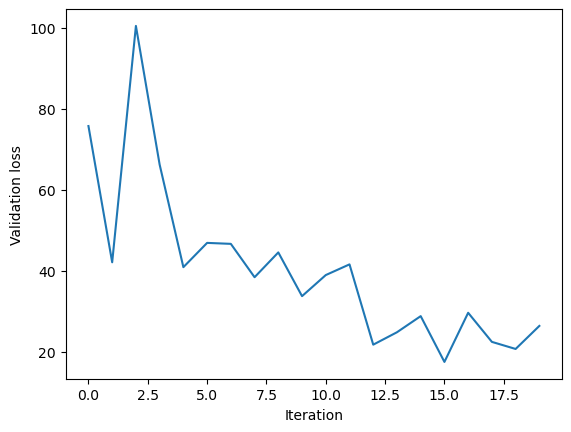

In [14]:
fig, ax = plt.subplots()
ax.plot(val_loss)
ax.set(xlabel='Iteration', ylabel='Validation loss')

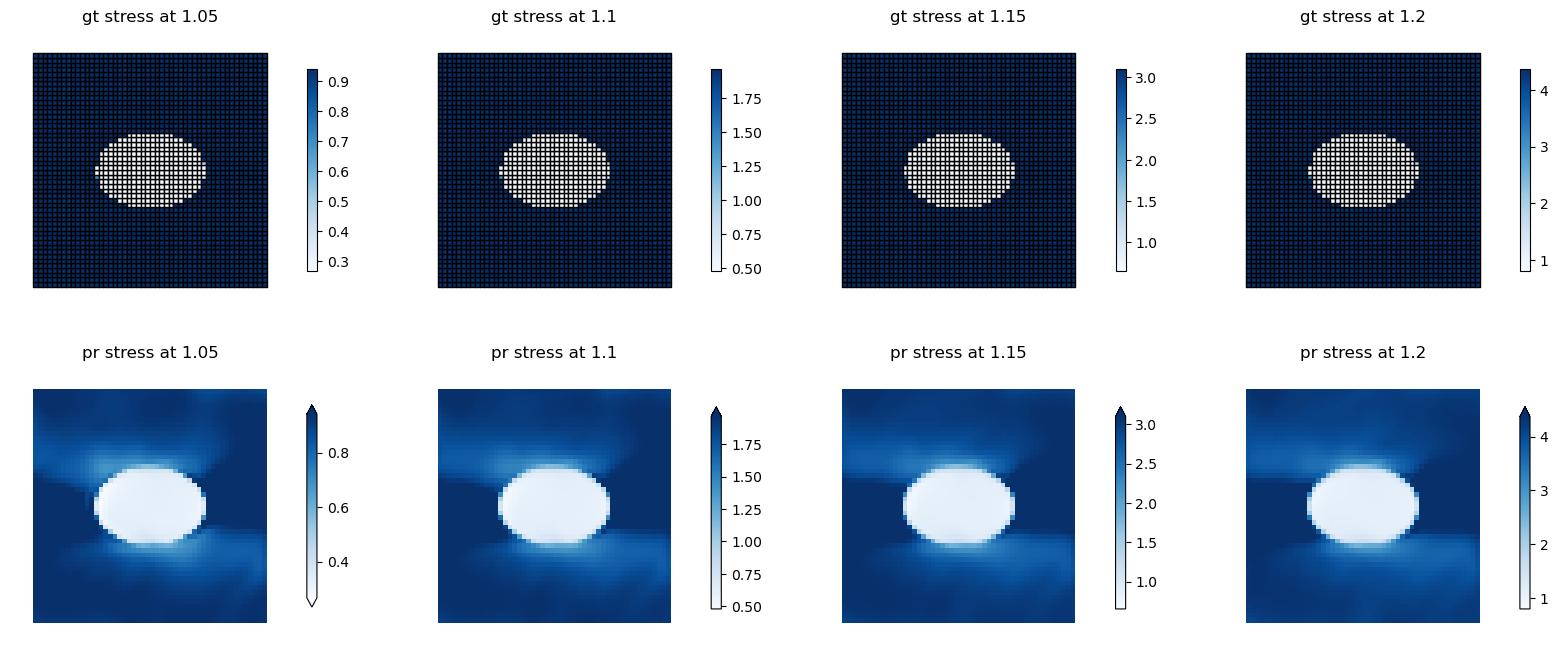

In [21]:
# Stiffness across the domain
fig, axes = plt.subplots(2,4,figsize=(20,8))
for lmb, ax in zip(lmb_hist, axes.T):
    ugrad = jnp.array([[lmb-1.0, 0.0], [0.0, lmb-1.0]])

    params_gt = []
    for xy in elem_X:
        params_gt.append(coords_2_params_gt(xy))
    params_gt = np.array(params_gt)
    params_pr = ff_nn(elem_X, Lambda_params)

    c_elem_gt = []
    c_elem_pr = []
    for params_gt_i, params_pr_i in zip(params_gt, params_pr):
        c_elem_gt.append(ThreeDElasticity(GOH_model).ugrad_2_P(ugrad, params_gt_i, 2)[0,0])
        c_elem_pr.append(ThreeDElasticity(NODE_w_unravel).ugrad_2_P(ugrad, params_pr_i, 2)[0,0])
    
    plotmesh(mesh.cells, mesh.points, c_elem_gt, title='gt stress at {}'.format(str(lmb)), ax=ax[0]); 
    extent = [np.min(c_elem_gt), np.max(c_elem_gt)]
    if extent[0] > np.min(c_elem_pr) and extent[1] < np.max(c_elem_pr):
        extend='both'
    elif extent[0] > np.min(c_elem_pr):
        extend='min'
    elif extent[1] < np.max(c_elem_pr):
        extend='max'
    plotmesh(mesh.cells, mesh.points, c_elem_pr, title='pr stress at {}'.format(str(lmb)), ax=ax[1], extent=extent, extend=extend,ec='None'); 

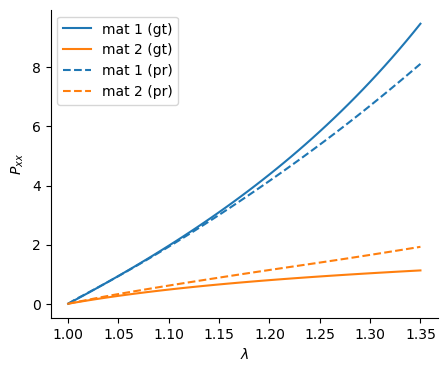

In [ ]:

mat1_params = coords_2_params_gt([0.5,0.9])
mat2_params = coords_2_params_gt([0.5,0.5])
mat1_P_gt = []
mat2_P_gt = []
mat1_P_pr = []
mat2_P_pr = []
# lmb_hist2 = [1.0, 1.005, 1.01, 1.02, 1.03, 1.04, 1.05, 1.10, 1.15, 1.20, 1.25, 1.30, 1.35]
lmb_hist2 = np.linspace(1,1.35)
for lmb in lmb_hist2:
    ugrad = jnp.array([[lmb-1.0, 0.0], [0.0, lmb-1.0]])
    mat1_P_gt.append(ThreeDElasticity(GOH_model).ugrad_2_P(ugrad, mat1_params, 2)[0,0])
    mat2_P_gt.append(ThreeDElasticity(GOH_model).ugrad_2_P(ugrad, mat2_params, 2)[0,0])

    mat1_params_pr = ff_nn(np.array([0.5, 0.9]), Lambda_params)
    mat2_params_pr = ff_nn(np.array([0.5, 0.5]), Lambda_params)
    mat1_P_pr.append(ThreeDElasticity(NODE_w_unravel).ugrad_2_P(ugrad, mat1_params_pr, 2)[0,0])
    mat2_P_pr.append(ThreeDElasticity(NODE_w_unravel).ugrad_2_P(ugrad, mat2_params_pr, 2)[0,0])

fig, ax = plt.subplots(figsize=(5,4))
ax.plot(lmb_hist2, mat1_P_gt, label='mat 1 (gt)')
ax.plot(lmb_hist2, mat2_P_gt, label='mat 2 (gt)')

fig.gca().set_prop_cycle(None)
ax.plot(lmb_hist2, mat1_P_pr, '--', label='mat 1 (pr)')
ax.plot(lmb_hist2, mat2_P_pr, '--', label='mat 2 (pr)')

ax.legend()
ax.set(xlabel='$\lambda$', ylabel='$P_{xx}$')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

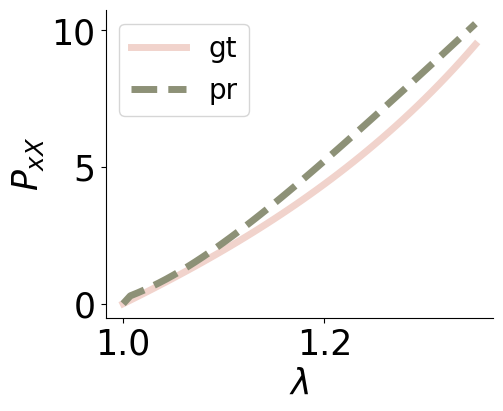

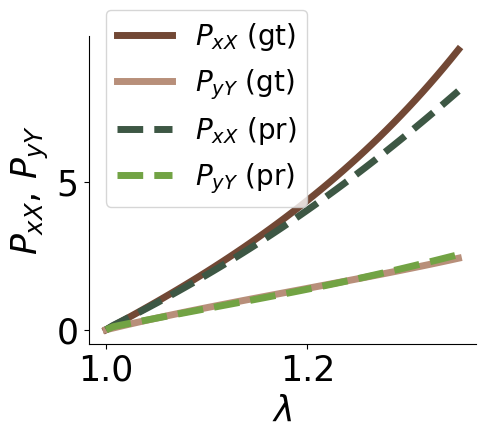

In [16]:
light_brown = "#f1d3cc"
mid_brown='#b88f7a'
dark_brown = "#724835"
light_green = "#8D9177" 
mid_green="#72A344"
dark_green = "#3D5744"
p1 = [0.0,0.0]
p2 = [0.75,0.5]
mat1_params = coords_2_params_gt(p1)
mat2_params = coords_2_params_gt(p2)
mat1_P_gt = []
mat2_Px_gt = []
mat2_Py_gt = []
mat1_P_pr = []
mat2_Px_pr = []
mat2_Py_pr = []
# lmb_hist2 = [1.05, 1.10, 1.15, 1.20, 1.25, 1.30, 1.35]
lmb_hist2 = np.linspace(1,1.35)
for lmb in lmb_hist2:
    ugrad = jnp.array([[lmb-1.0, 0.0], [0.0, lmb-1.0]])
    mat1_P_gt.append(ThreeDElasticity(GOH_model).ugrad_2_P(ugrad, mat2_params, 2)[0,0])
    mat2_Px_gt.append(ThreeDElasticity(GOH_model).ugrad_2_P(ugrad, mat1_params, 2)[0,0])
    mat2_Py_gt.append(ThreeDElasticity(GOH_model).ugrad_2_P(ugrad, mat1_params, 2)[1,1])

    mat1_params_pr = ff_nn(np.array(p1), Lambda_params)
    mat2_params_pr = ff_nn(np.array(p2), Lambda_params)
    mat1_P_pr.append(ThreeDElasticity(NODE_w_unravel).ugrad_2_P(ugrad, mat2_params_pr, 2)[0,0])
    mat2_Px_pr.append(ThreeDElasticity(NODE_w_unravel).ugrad_2_P(ugrad, mat1_params_pr, 2)[0,0])
    mat2_Py_pr.append(ThreeDElasticity(NODE_w_unravel).ugrad_2_P(ugrad, mat1_params_pr, 2)[1,1])


fig, ax = plt.subplots(figsize=(5,4))
ax.plot(lmb_hist2, mat1_P_gt, label='gt',color=light_brown, linewidth=5)
ax.plot(lmb_hist2, mat1_P_pr, '--', label='pr',color=light_green, linewidth=5)
ax.legend(fontsize=20)
#ax.set(xlabel='$\lambda$', ylabel='$P_{xx}$')
ax.set_xlabel(r'$\lambda$',fontsize=25)
ax.set_ylabel(r'$P_{xX}$',fontsize=25)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.tick_params(axis='both', labelsize=25)


fig, ax = plt.subplots(figsize=(5,4))
ax.plot(lmb_hist2, mat2_Px_gt, label='$P_{xX}$ (gt)',color=dark_brown, linewidth=5)
ax.plot(lmb_hist2, mat2_Py_gt, label='$P_{yY}$ (gt)',color=mid_brown, linewidth=5)
fig.gca().set_prop_cycle(None)
ax.plot(lmb_hist2, mat2_Px_pr, '--', label='$P_{xX}$ (pr)',color=dark_green, linewidth=5)
ax.plot(lmb_hist2, mat2_Py_pr, '--', label='$P_{yY}$ (pr)',color=mid_green, linewidth=5)
ax.legend(fontsize=20, bbox_to_anchor=(.6, .4))
#ax.set(xlabel='$\lambda$', ylabel='$P_{xx}$')
ax.set_xlabel(r'$\lambda$',fontsize=25)
ax.set_ylabel(r'$P_{xX},\, P_{yY}$',fontsize=25)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.tick_params(axis='both', labelsize=25)


In [17]:
mat1_P_gt=np.array(mat1_P_gt)
mat2_Px_gt=np.array(mat2_Px_gt)
mat2_Py_gt=np.array(mat2_Py_gt)
mat1_P_pr=np.array(mat1_P_pr)
mat2_Px_pr=np.array(mat2_Px_pr)
mat2_Py_pr=np.array(mat2_Py_pr)
print(np.linalg.norm(mat1_P_gt-mat1_P_pr)/np.linalg.norm(mat1_P_gt))
print(np.linalg.norm(mat2_Px_gt-mat2_Px_pr)/np.linalg.norm(mat2_Px_gt))
print(np.linalg.norm(mat2_Py_gt-mat2_Py_pr)/np.linalg.norm(mat2_Py_gt))

0.1454573509241687
0.11240659990032621
0.03210056392743196


0.1454573509241687

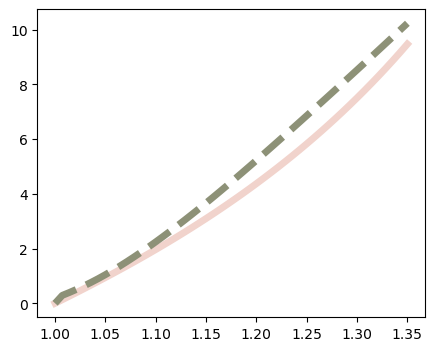

In [27]:
fig, ax = plt.subplots(figsize=(5,4))
ax.plot(lmb_hist2, mat1_P_gt, label='gt',color=light_brown, linewidth=5)
ax.plot(lmb_hist2, mat1_P_pr, '--', label='pr',color=light_green, linewidth=5)
np.linalg.norm(mat1_P_gt-mat1_P_pr)/np.linalg.norm(mat1_P_gt)

0.11240659990032621

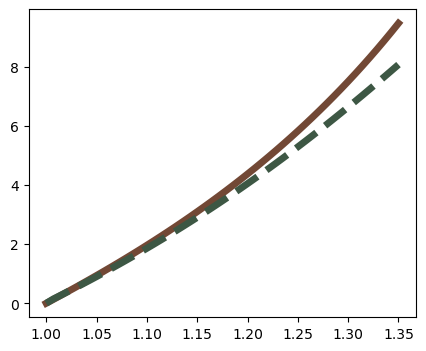

In [31]:
fig, ax = plt.subplots(figsize=(5,4))
ax.plot(lmb_hist2, mat2_Px_gt, label='$P_{xX}$ (gt)',color=dark_brown, linewidth=5)
ax.plot(lmb_hist2, mat2_Px_pr, '--', label='$P_{xX}$ (pr)',color=dark_green, linewidth=5)
np.linalg.norm(mat2_Px_gt-mat2_Px_pr)/np.linalg.norm(mat2_Px_gt)

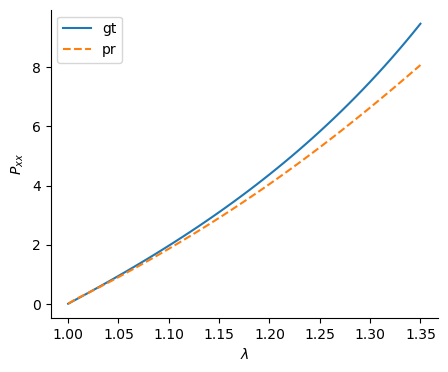

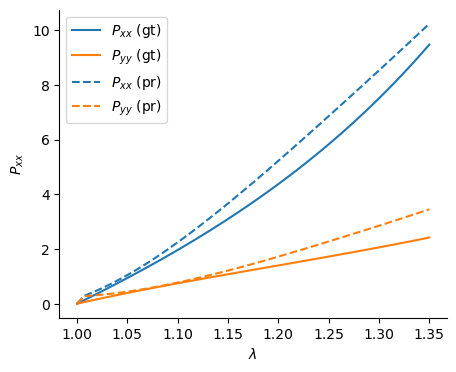

In [67]:
mat1_params = coords_2_params_gt([0.0,0.0])
mat2_params = coords_2_params_gt([0.75,0.5])
mat1_P_gt = []
mat2_Px_gt = []
mat2_Py_gt = []
mat1_P_pr = []
mat2_Px_pr = []
mat2_Py_pr = []
# lmb_hist2 = [1.05, 1.10, 1.15, 1.20, 1.25, 1.30, 1.35]
lmb_hist2 = np.linspace(1,1.35)
for lmb in lmb_hist2:
    ugrad = jnp.array([[lmb-1.0, 0.0], [0.0, lmb-1.0]])
    mat1_P_gt.append(ThreeDElasticity(GOH_model).ugrad_2_P(ugrad, mat1_params, 2)[0,0])
    mat2_Px_gt.append(ThreeDElasticity(GOH_model).ugrad_2_P(ugrad, mat2_params, 2)[0,0])
    mat2_Py_gt.append(ThreeDElasticity(GOH_model).ugrad_2_P(ugrad, mat2_params, 2)[1,1])

    mat1_params_pr = ff_nn(np.array([0.0, 0.0]), Lambda_params)
    mat2_params_pr = ff_nn(np.array([0.75,0.5]), Lambda_params)
    mat1_P_pr.append(ThreeDElasticity(NODE_w_unravel).ugrad_2_P(ugrad, mat1_params_pr, 2)[0,0])
    mat2_Px_pr.append(ThreeDElasticity(NODE_w_unravel).ugrad_2_P(ugrad, mat2_params_pr, 2)[0,0])
    mat2_Py_pr.append(ThreeDElasticity(NODE_w_unravel).ugrad_2_P(ugrad, mat2_params_pr, 2)[1,1])


fig, ax = plt.subplots(figsize=(5,4))
ax.plot(lmb_hist2, mat1_P_gt, label='gt')
ax.plot(lmb_hist2, mat1_P_pr, '--', label='pr')
ax.legend()
ax.set(xlabel='$\lambda$', ylabel='$P_{xx}$')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)


fig, ax = plt.subplots(figsize=(5,4))
ax.plot(lmb_hist2, mat2_Px_gt, label='$P_{xx}$ (gt)')
ax.plot(lmb_hist2, mat2_Py_gt, label='$P_{yy}$ (gt)')
fig.gca().set_prop_cycle(None)
ax.plot(lmb_hist2, mat2_Px_pr, '--', label='$P_{xx}$ (pr)')
ax.plot(lmb_hist2, mat2_Py_pr, '--', label='$P_{yy}$ (pr)')
ax.legend()
ax.set(xlabel='$\lambda$', ylabel='$P_{xx}$')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)


##### plots of P's wrt F(X,t)

In [23]:
range_minmax=np.zeros((2,))
id_f=0
for lmb, ax in zip(lmb_hist, axes.T):
    F=F_hist_goh[id_f]

    params_gt = []
    for xy in elem_X:
        params_gt.append(coords_2_params_gt(xy))
    params_gt = np.array(params_gt)
    params_pr = ff_nn(elem_X, Lambda_params)
    # E = E_fun(F)
    # evals, efuns = jnp.linalg.eigh(E)
    # print(evals.shape)
    E_11, E_22 = evals.T
    c_elem_gt = []
    c_elem_pr = []
    id_elem=0
    for params_gt_i, params_pr_i in zip(params_gt, params_pr):
        ugrad=jnp.squeeze(F[id_elem,:,:])-jnp.eye(2)
        c_elem_gt.append(ThreeDElasticity(GOH_model).ugrad_2_P(ugrad, params_gt_i, 2)[0,0])
        c_elem_pr.append(ThreeDElasticity(NODE_w_unravel).ugrad_2_P(ugrad, params_pr_i, 2)[0,0])
        id_elem+=1
    if lmb==1.05:
        range_minmax[0]=np.array(c_elem_pr).min()
        range_minmax[1]=np.array(c_elem_pr).max()
    else:
        range_minmax[0]=np.min([np.array(c_elem_pr).min(),range_minmax[0]])
        range_minmax[1]=np.max([np.array(c_elem_pr).max(),range_minmax[1]])
    id_f+=1
 

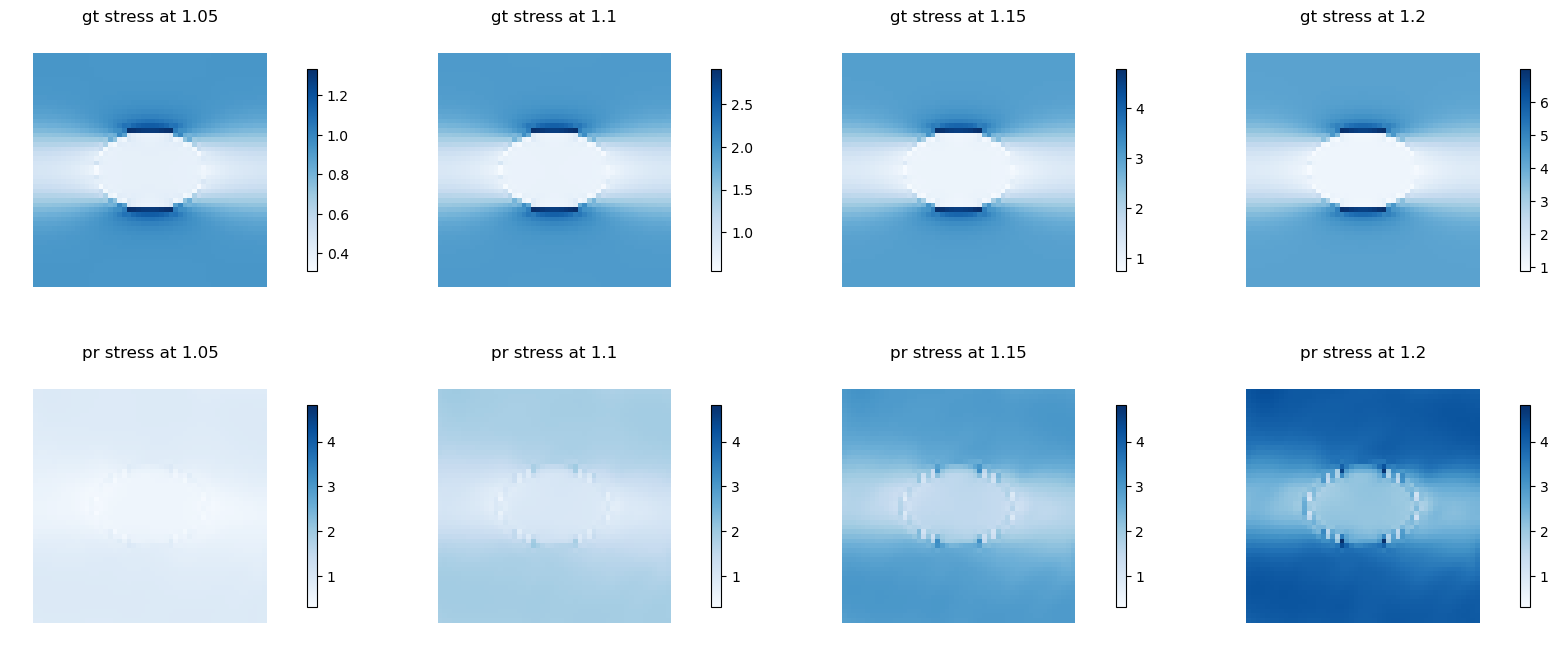

In [84]:

fig, axes = plt.subplots(2,4,figsize=(20,8))
id_f=0
for lmb, ax in zip(lmb_hist, axes.T):
    F=F_hist_goh[id_f]

    params_gt = []
    for xy in elem_X:
        params_gt.append(coords_2_params_gt(xy))
    params_gt = np.array(params_gt)
    params_pr = ff_nn(elem_X, Lambda_params)
    # E = E_fun(F)
    # evals, efuns = jnp.linalg.eigh(E)
    # print(evals.shape)
    E_11, E_22 = evals.T
    c_elem_gt = []
    c_elem_pr = []
    id_elem=0
    for params_gt_i, params_pr_i in zip(params_gt, params_pr):
        ugrad=jnp.squeeze(F[id_elem,:,:])-jnp.eye(2)
        c_elem_gt.append(ThreeDElasticity(GOH_model).ugrad_2_P(ugrad, params_gt_i, 2)[0,0])
        c_elem_pr.append(ThreeDElasticity(NODE_w_unravel).ugrad_2_P(ugrad, params_pr_i, 2)[0,0])
        id_elem+=1
    
    plotmesh(mesh.cells, mesh.points, c_elem_gt, title='gt stress at {}'.format(str(lmb)), ax=ax[0],ec='None'); 
    extent = [np.min(c_elem_gt), np.max(c_elem_gt)]
    if extent[0] > np.min(c_elem_pr) and extent[1] < np.max(c_elem_pr):
        extend='both'
    elif extent[0] > np.min(c_elem_pr):
        extend='min'
    elif extent[1] < np.max(c_elem_pr):
        extend='max'
    #plotmesh(mesh.cells, mesh.points, c_elem_pr, title='pr stress at {}'.format(str(lmb)), ax=ax[1], extent=extent, extend=extend,ec='None');
    plotmesh_updated(mesh.cells, mesh.points, c_elem_pr, range_minmax[0],range_minmax[1],title=f'pr stress at {lmb}', ax=ax[1],ec='None')
    id_f+=1
 

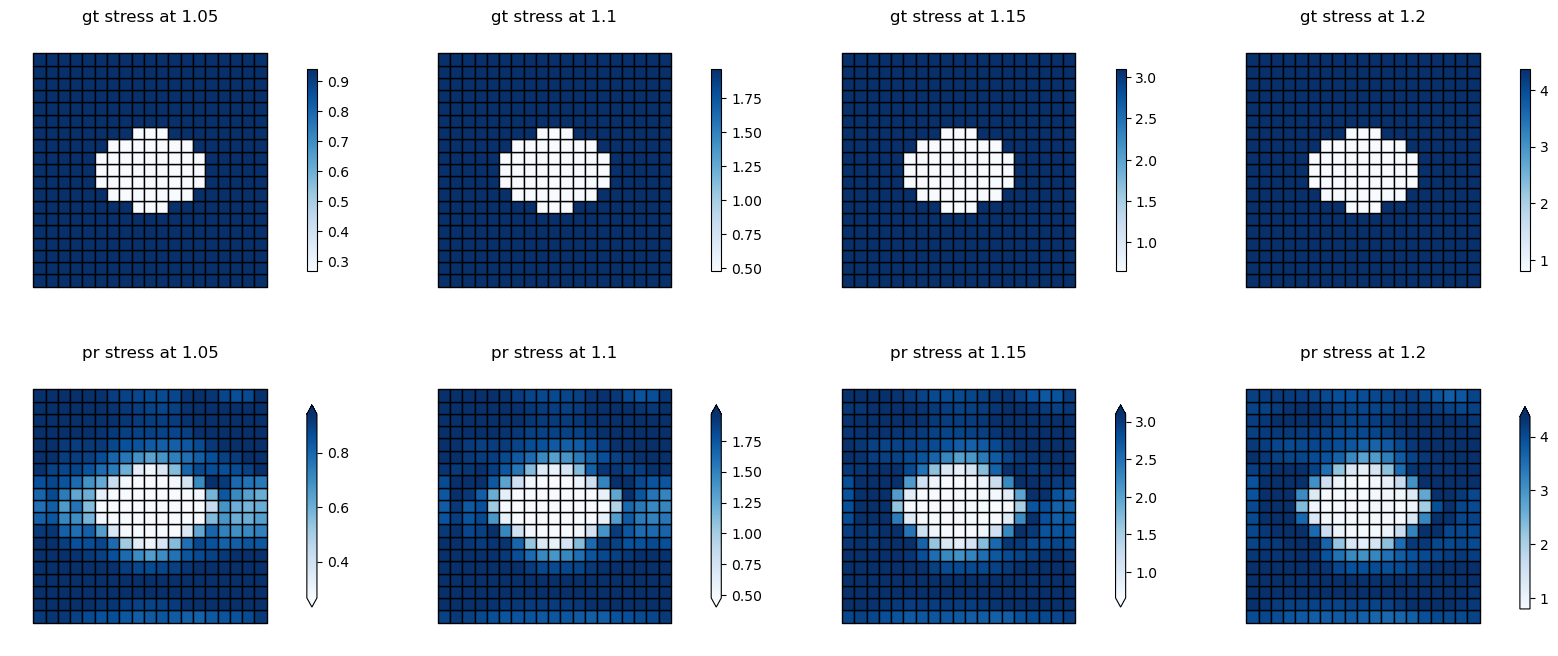

In [32]:
# Stiffness across the domain
fig, axes = plt.subplots(2,4,figsize=(20,8))
for lmb, ax in zip(lmb_hist, axes.T):
    ugrad = jnp.array([[lmb-1.0, 0.0], [0.0, lmb-1.0]])

    params_gt = []
    for xy in elem_X:
        params_gt.append(coords_2_params_gt(xy))
    params_gt = np.array(params_gt)
    params_pr = ff_nn(elem_X, Lambda_params)

    c_elem_gt = []
    c_elem_pr = []
    for params_gt_i, params_pr_i in zip(params_gt, params_pr):
        c_elem_gt.append(ThreeDElasticity(GOH_model).ugrad_2_P(ugrad, params_gt_i, 2)[0,0])
        c_elem_pr.append(ThreeDElasticity(NODE_w_unravel).ugrad_2_P(ugrad, params_pr_i, 2)[0,0])
    
    plotmesh(mesh.cells, mesh.points, c_elem_gt, title='gt stress at {}'.format(str(lmb)), ax=ax[0]); 
    extent = [np.min(c_elem_gt), np.max(c_elem_gt)]
    if extent[0] > np.min(c_elem_pr) and extent[1] < np.max(c_elem_pr):
        extend='both'
    elif extent[0] > np.min(c_elem_pr):
        extend='min'
    elif extent[1] < np.max(c_elem_pr):
        extend='max'
    plotmesh(mesh.cells, mesh.points, c_elem_pr, title='pr stress at {}'.format(str(lmb)), ax=ax[1], extent=extent, extend=extend); 